(704000, 2)


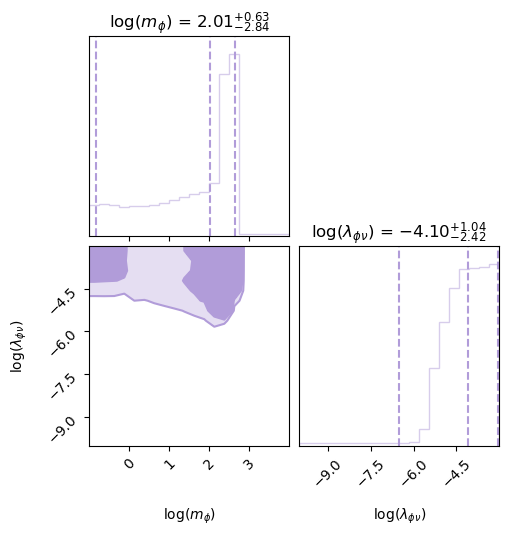

In [ ]:
import corner
import matplotlib.pyplot as plt
import numpy as np

effective_data_file = [
    '15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
    '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
    '19.02', '19.56', '19.83', '19.99'
]

# 1. Use a list to collect the arrays
data_list = []

for file_id in effective_data_file:
    path = f'F:/Neutrino_SI/Bin/smellycat260622/data/2d_m{file_id}_5e5_p32_log_osc.npy'
    # 2. Load and append to the list
    arr = np.load(path) # shape (2000, 2)
    data_list.append(arr)

# 3. Concatenate the list of arrays into one (axis=0 is default)
data_all = np.concatenate(data_list, axis=0)

print(data_all.shape)

fig = corner.corner(data_all, labels=[r'log($m_\phi$)', r'log($\lambda_{\phi\nu}$)'],
                    show_titles=True,quantiles=[0.025, 0.5, 0.975], plot_datapoints=False,color="#B19CD9",                   # Set the primary color
                    fill_contours=True,             # Fill the contours
                    plot_density=False,             # Remove the background pixel shading
                    # smooth=1.2,                     # Smooth the 2D contours
                    # smooth1d=1.2,                   # Smooth the 1D histograms
                    levels=(0.68, 0.95),            # Standard 1-sigma and 2-sigma levels
                    hist_kwargs={"alpha": 0.5} # Fill the 1D marginals
                    )

fig

Removed no burn in


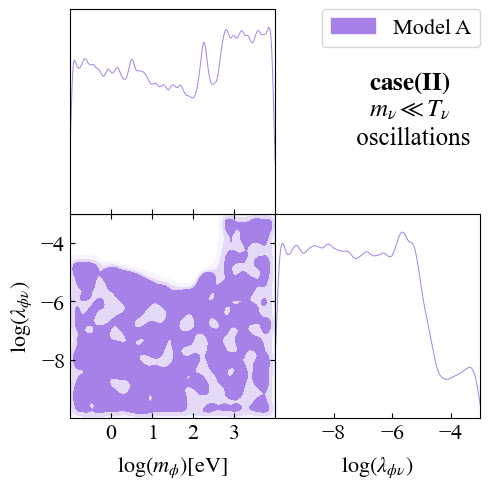

In [5]:

import numpy as np
import corner
from getdist import MCSamples, plots

data_1d = np.load('F:/Neutrino_SI/Bin/smellycat260622/data/1d_8p_5e5_p32_log_osc.npy')

model_names = ['Model A', 'Model B']
names = [r'\mathrm{log}(m_\phi)\mathrm{[eV]}', r'\mathrm{log}(\lambda_{\phi\nu})']
samples_A = MCSamples(samples=data_1d[:,-2:], names=names, labels=names, label='1d')


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'


g = plots.get_subplot_plotter(width_inch=5)

limits = {
r'log(m_\phi)/eV': [-1, 4], 
r'log(\lambda_{\phi\nu})': [-10, -3]          
}

g.settings.axes_labelsize = 18
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 18

g.settings.num_plot_contours = 3
g.settings.alpha_filled_add = 0.9
g.settings.solid_contour_palefactor = 0.7
g.settings.alpha_factor_contour_lines = 0

g.triangle_plot(
    samples_A,
    filled=True, 
    contour_colors= ["#A682E8"], # Optional: override default colors
    legend_labels=[model_names[0]], # Optional: legend labels
    param_limits={names[0]: (-1, 4), names[1]: (-10, -3)}

)
my_text = r'$\mathbf{case(II)}$' +'\n' + r'$m_\nu \ll T_\nu$' + '\n oscillations'
g.fig.text(0.95, 0.85, my_text,
           fontsize=18, 
           ha='right', 
           va='top',
           multialignment='center')

g.export(r"F:\Neutrino_SI\Plots\1d_corner_osc.pdf")

g.fig

Removed no burn in


\mathrm{log}(m_\phi)\mathrm{[eV]}: Peak=2.49, 2-sigma HPD=[-3.30, +0.28]
\mathrm{log}(\lambda_{\phi\nu}): Peak=-3.48, 2-sigma HPD=[-2.07, +0.61]


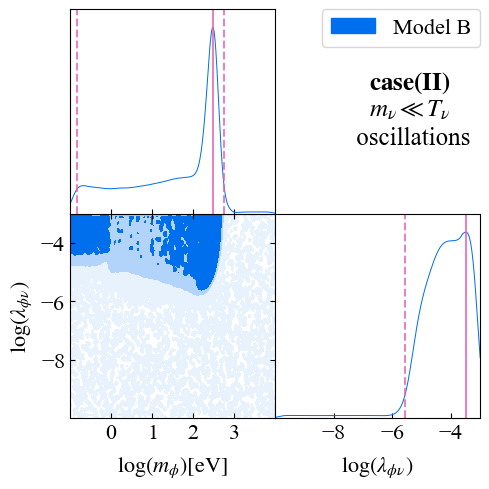

In [6]:
samples_B = MCSamples(samples=data_all, names=names, labels=names, label='2d')

g = plots.get_subplot_plotter(width_inch=5)

g.settings.axes_labelsize = 18
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 18

g.settings.num_plot_contours = 3
g.settings.alpha_filled_add = 0.9
g.settings.solid_contour_palefactor = 0.7
g.settings.alpha_factor_contour_lines = 0

g.triangle_plot(
    [samples_B],
    filled=True, 
    contour_colors=["#006FED"], # Optional: override default colors
    # title_limit=2, # Optional: adds 1D mean and 1-sigma limits above the diagonal
    legend_labels=[model_names[1]], # Optional: legend labels
    param_limits={names[0]: (-1, 4), names[1]: (-10, -3)}
)


for i, param_name in enumerate(names):
    
    density = samples_B.get1DDensity(param_name)
    x = density.x
    P = density.P
    
    sort_idx = np.argsort(P)[::-1]
    sorted_P = P[sort_idx]
    
    cum_prob = np.cumsum(sorted_P)
    cum_prob /= cum_prob[-1] # Normalize the probabilities
    
    idx_1sigma = sort_idx[cum_prob <= 0.6827]
    idx_2sigma = sort_idx[cum_prob <= 0.9545]
    
    peak_idx = np.argmax(P)
    peak_value = x[peak_idx]
    ax = g.subplots[i, i]
    
    ax.axvline(peak_value, color='#df65b0', ls='-', lw=1.5, alpha=0.8)

    if_s_1= False
    if_s_2= True

    if if_s_1:
        if len(idx_1sigma) > 0:
            lower_1sigma = np.min(x[idx_1sigma])
            upper_1sigma = np.max(x[idx_1sigma])
            # add a horizontal line at the 1-sigma HPD level
            # ax.axhline(P[idx_1sigma].min(), color='blue', ls='-', lw=1.5, alpha=0.8)

            # add a vertical line at the peak value
            print(f"{param_name}: Peak={peak_value:.2f}, 1-sigma HPD=[-{peak_value-lower_1sigma:.2f}, +{upper_1sigma-peak_value:.2f}]")

            ax.axvline(lower_1sigma, color='#df65b0', ls=':', lw=1.5, alpha=0.8)
            ax.axvline(upper_1sigma, color='#df65b0', ls=':', lw=1.5, alpha=0.8)
        
    # Find Edges and Draw the 2-sigma HPD lines

    if if_s_2:
        if len(idx_2sigma) > 0:
            lower_2sigma = np.min(x[idx_2sigma])
            upper_2sigma = np.max(x[idx_2sigma])

            print(f"{param_name}: Peak={peak_value:.2f}, 2-sigma HPD=[-{peak_value-lower_2sigma:.2f}, +{upper_2sigma-peak_value:.2f}]")
            ax.axvline(lower_2sigma, color='#df65b0', ls='--', lw=1.5, alpha=0.8)
            # if i != 0:  # Only plot the 2-sigma lines for the second parameter
            ax.axvline(upper_2sigma, color='#df65b0', ls='--', lw=1.5, alpha=0.8)

            
my_text = r'$\mathbf{case(II)}$' +'\n' + r'$m_\nu \ll T_\nu$' + '\n oscillations'
g.fig.text(0.95, 0.85, my_text,
           fontsize=18, 
           ha='right', 
           va='top',
           multialignment='center')

g.export(r"F:\Neutrino_SI\Plots\2d_corner_osc.pdf")

g.fig
